In [1]:
# # Deep Reinforcement Learning - Lab Assignment 1

# ## Part 2: Dynamic Programming

# ### Group Number: 222

# Environment:
# - Grid Size = 5×5
# - Battery Capacity = 10
# - Rescue Targets = 2
# - Charging Stations = 1
# - Danger Zones = 3
# - Blocked Cells = 2
# - Wind Probability = 20%

# Method Used:
# # Value Iteration
from datetime import datetime
import platform
import socket

print("="*60)
print("DRL Assignment 1 - Dynamic Programming")
print("Group Number: 222")
print("Timestamp:", datetime.now())
print("Machine:", socket.gethostname())
print("OS:", platform.platform())
print("="*60)

DRL Assignment 1 - Dynamic Programming
Group Number: 222
Timestamp: 2026-06-07 14:10:13.600655
Machine: DESKTOP-1UIA5UO
OS: Windows-11-10.0.26200-SP0


In [2]:
# # Task 1: Custom Drone Rescue Environment

# ## Question

# Implement a custom Drone Rescue Environment with:

# - Start position (S)
# - Rescue targets (R)
# - Charging station (C)
# - Danger zones (D)
# - Wind zone (W)
# - Blocked cells (X)

# The environment should be configured according to Group 222 requirements and rendered for visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

random.seed(222)
np.random.seed(222)

In [3]:
GRID_SIZE = 5
MAX_BATTERY = 10
WIND_PROBABILITY = 0.20

grid = np.array([
    ['S', 'F', 'F', 'D', 'F'],
    ['F', 'X', 'F', 'F', 'R'],
    ['F', 'F', 'C', 'D', 'F'],
    ['W', 'F', 'X', 'F', 'F'],
    ['R', 'F', 'D', 'F', 'F']
])

print("Grid Size:", GRID_SIZE, "x", GRID_SIZE)
print("Maximum Battery:", MAX_BATTERY)
print("Wind Probability:", WIND_PROBABILITY)

print("\nEnvironment Grid:")
print(grid)

Grid Size: 5 x 5
Maximum Battery: 10
Wind Probability: 0.2

Environment Grid:
[['S' 'F' 'F' 'D' 'F']
 ['F' 'X' 'F' 'F' 'R']
 ['F' 'F' 'C' 'D' 'F']
 ['W' 'F' 'X' 'F' 'F']
 ['R' 'F' 'D' 'F' 'F']]


In [4]:
def render_grid(grid):

    print("\nDrone Rescue Environment\n")

    for row in grid:
        print("  ".join(row))

render_grid(grid)


Drone Rescue Environment

S  F  F  D  F
F  X  F  F  R
F  F  C  D  F
W  F  X  F  F
R  F  D  F  F


In [5]:
# ## Environment Description

# Legend:

# - S = Start Position
# - F = Free Cell
# - R = Rescue Target
# - C = Charging Station
# - D = Danger Zone
# - W = Wind Zone
# - X = Blocked Cell

# For Group 222:

# - Grid Size = 5×5
# - Battery Capacity = 10
# - Rescue Targets = 2
# - Charging Stations = 1
# - Danger Zones = 3
# - Blocked Cells = 2
# - Wind Probability = 20%

# The drone starts from the top-left corner (0,0).
# State Space Representation

## Question

# Define the state representation used by the Dynamic Programming algorithm.

# Each state contains:

# 1. Drone Position (row, column)
# 2. Current Battery Level
# 3. Rescue Status of all rescue targets
start_state = (
    0,          # row
    0,          # column
    10,         # battery
    (0, 0)      # rescue status
)

print("Initial State:")
print(start_state)

Initial State:
(0, 0, 10, (0, 0))


In [6]:
# # Drone Rescue Environment Implementation

# ## Question

# Implement a custom environment with:

# - reset()
# - step(action)
# - render()

# The environment must correctly handle:

# - Battery updates
# - Rescue target removal
# - Charging stations
# - Danger zones
# - Wind zones
# - Blocked cells
# - Reward computation

In [21]:
class DroneRescueEnvironment:

    def __init__(self):

        self.grid = grid
        self.max_battery = MAX_BATTERY

        self.start_position = (0, 0)

        self.rescue_locations = {
            (1, 4),
            (4, 0)
        }

        self.reset()

    def reset(self):

        self.position = self.start_position

        self.battery = self.max_battery

        self.rescued_targets = set()

        self.done = False

        return self.get_state()

    def get_state(self):

        rescue_status = tuple(
            int(target in self.rescued_targets)
            for target in sorted(self.rescue_locations)
        )

        return (
            self.position[0],
            self.position[1],
            self.battery,
            rescue_status
        )
    
    def render(self):
        temp_grid = self.grid.copy()
        r, c = self.position
        temp_grid[r][c] = 'A'
        print("\nCurrent Environment\n")
        for row in temp_grid:
            print(" ".join(row))
        print("\nBattery:", self.battery)
        print("Rescued:", len(self.rescued_targets))
    
    

In [22]:
    def step(self, action):

        if self.done:
            return self.get_state(), 0, True

        reward = -1

        row, col = self.position

        # Battery consumption
        self.battery -= 1

        # Wind effect
        current_cell = self.grid[row][col]

        if current_cell == 'W':

            if random.random() < WIND_PROBABILITY:

                action = random.choice(
                    ["UP", "DOWN", "LEFT", "RIGHT"]
                )

        new_row = row
        new_col = col

        if action == "UP":
            new_row -= 1

        elif action == "DOWN":
            new_row += 1

        elif action == "LEFT":
            new_col -= 1

        elif action == "RIGHT":
            new_col += 1

        elif action == "HOVER":
            pass

        # Boundary check
        if (
            0 <= new_row < GRID_SIZE and
            0 <= new_col < GRID_SIZE
        ):

            if self.grid[new_row][new_col] != 'X':

                self.position = (
                    new_row,
                    new_col
                )

        row, col = self.position

        cell = self.grid[row][col]
                # Charging station
        if cell == 'C':

            reward += 5

            self.battery = self.max_battery

        # Danger zone
        if cell == 'D':

            reward -= 10

        # Rescue target
        if (
            (row, col) in self.rescue_locations
            and
            (row, col) not in self.rescued_targets
        ):

            reward += 20

            self.rescued_targets.add(
                (row, col)
            )

        # Battery exhausted
        if self.battery <= 0:

            reward -= 20

            self.done = True

        # All rescues completed
        if len(self.rescued_targets) == len(
            self.rescue_locations
        ):

            self.done = True

        return (
            self.get_state(),
            reward,
            self.done
        )

In [23]:
    def render(self):

        temp_grid = self.grid.copy()

        r, c = self.position

        temp_grid[r][c] = 'A'

        print("\nCurrent Environment\n")

        for row in temp_grid:
            print(" ".join(row))

        print(
            "\nBattery:",
            self.battery
        )

        print(
            "Rescued:",
            len(self.rescued_targets)
        )

In [24]:
env = DroneRescueEnvironment()

state = env.reset()

print("Initial State:")
print(state)

env.render()

Initial State:
(0, 0, 10, (0, 0))

Current Environment

A F F D F
F X F F R
F F C D F
W F X F F
R F D F F

Battery: 10
Rescued: 0


In [27]:
env = DroneRescueEnvironment()

state = env.reset()

print(state)

env.render()

(0, 0, 10, (0, 0))

Current Environment

A F F D F
F X F F R
F F C D F
W F X F F
R F D F F

Battery: 10
Rescued: 0


In [28]:
print(DroneRescueEnvironment.__dict__.keys())

dict_keys(['__module__', '__firstlineno__', '__init__', 'reset', 'get_state', 'render', '__static_attributes__', '__dict__', '__weakref__', '__doc__'])


In [29]:
def step(self, action):

    reward = -1

    row, col = self.position

    self.battery -= 1

    new_row = row
    new_col = col

    if action == "UP":
        new_row -= 1

    elif action == "DOWN":
        new_row += 1

    elif action == "LEFT":
        new_col -= 1

    elif action == "RIGHT":
        new_col += 1

    if (
        0 <= new_row < GRID_SIZE and
        0 <= new_col < GRID_SIZE and
        self.grid[new_row][new_col] != 'X'
    ):
        self.position = (new_row, new_col)

    row, col = self.position
    cell = self.grid[row][col]

    if cell == 'C':
        reward += 5
        self.battery = self.max_battery

    if cell == 'D':
        reward -= 10

    if (
        (row, col) in self.rescue_locations and
        (row, col) not in self.rescued_targets
    ):
        reward += 20
        self.rescued_targets.add((row, col))

    done = False

    if self.battery <= 0:
        done = True

    if len(self.rescued_targets) == len(self.rescue_locations):
        done = True

    return self.get_state(), reward, done

In [30]:
print(DroneRescueEnvironment.__dict__.keys())

dict_keys(['__module__', '__firstlineno__', '__init__', 'reset', 'get_state', 'render', '__static_attributes__', '__dict__', '__weakref__', '__doc__'])


In [32]:
class DroneRescueEnvironment:

    def __init__(self):

        self.position = (0, 0)
        self.battery = 10

    def reset(self):

        self.position = (0, 0)
        self.battery = 10

        return self.position

    def get_state(self):

        return (
            self.position[0],
            self.position[1],
            self.battery
        )

    def step(self, action):

        row, col = self.position

        if action == "RIGHT":
            col += 1

        elif action == "LEFT":
            col -= 1

        elif action == "UP":
            row -= 1

        elif action == "DOWN":
            row += 1

        row = max(0, min(4, row))
        col = max(0, min(4, col))

        self.position = (row, col)

        self.battery -= 1

        return self.get_state(), -1, False

    def render(self):

        print(
            "Position:",
            self.position
        )

In [33]:
env = DroneRescueEnvironment()

print(DroneRescueEnvironment.__dict__.keys())

dict_keys(['__module__', '__firstlineno__', '__init__', 'reset', 'get_state', 'step', 'render', '__static_attributes__', '__dict__', '__weakref__', '__doc__'])


In [34]:
actions = ["RIGHT", "RIGHT", "DOWN"]

for action in actions:

    state, reward, done = env.step(action)

    print(state, reward, done)

(0, 1, 9) -1 False
(0, 2, 8) -1 False
(1, 2, 7) -1 False


In [35]:
states = []

for row in range(5):
    for col in range(5):

        if grid[row][col] != 'X':

            states.append(
                (row, col)
            )

print("Total Reachable States:")
print(len(states))

print("\nStates:")
print(states)

Total Reachable States:
23

States:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 0), (3, 1), (3, 3), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


In [36]:
V = {}

for state in states:
    V[state] = 0

print("Initial Value Function")

for state in list(V.keys())[:10]:
    print(state, ":", V[state])

Initial Value Function
(0, 0) : 0
(0, 1) : 0
(0, 2) : 0
(0, 3) : 0
(0, 4) : 0
(1, 0) : 0
(1, 2) : 0
(1, 3) : 0
(1, 4) : 0
(2, 0) : 0


In [37]:
import time

gamma = 0.9
theta = 0.001

actions = [
    "UP",
    "DOWN",
    "LEFT",
    "RIGHT"
]

start_time = time.time()

iterations = 0

while True:

    delta = 0

    new_V = V.copy()

    for state in states:

        row, col = state

        action_values = []

        for action in actions:

            next_row = row
            next_col = col

            if action == "UP":
                next_row -= 1

            elif action == "DOWN":
                next_row += 1

            elif action == "LEFT":
                next_col -= 1

            elif action == "RIGHT":
                next_col += 1

            # Boundary check
            if not (
                0 <= next_row < 5 and
                0 <= next_col < 5
            ):
                next_row, next_col = row, col

            # Blocked cell check
            elif grid[next_row][next_col] == 'X':
                next_row, next_col = row, col

            reward = -1

            cell = grid[next_row][next_col]

            if cell == 'R':
                reward = 20

            elif cell == 'C':
                reward = 5

            elif cell == 'D':
                reward = -10

            next_state = (
                next_row,
                next_col
            )

            value = reward + gamma * V[next_state]

            action_values.append(value)

        new_V[state] = max(action_values)

        delta = max(
            delta,
            abs(new_V[state] - V[state])
        )

    V = new_V

    iterations += 1

    if delta < theta:
        break

runtime = time.time() - start_time

print("Value Iteration Completed")
print("Iterations:", iterations)
print("Final Delta:", delta)
print("Runtime:", round(runtime, 4), "seconds")

Value Iteration Completed
Iterations: 95
Final Delta: 0.0009995991610765032
Runtime: 0.0625 seconds


In [38]:
print("Optimal State Values\n")

for state, value in V.items():

    print(
        state,
        "->",
        round(value, 2)
    )

Optimal State Values

(0, 0) -> 143.08
(0, 1) -> 143.08
(0, 2) -> 160.09
(0, 3) -> 178.99
(0, 4) -> 199.99
(1, 0) -> 160.09
(1, 2) -> 178.99
(1, 3) -> 199.99
(1, 4) -> 199.99
(2, 0) -> 178.99
(2, 1) -> 160.09
(2, 2) -> 160.09
(2, 3) -> 178.99
(2, 4) -> 199.99
(3, 0) -> 199.99
(3, 1) -> 178.99
(3, 3) -> 160.09
(3, 4) -> 178.99
(4, 0) -> 199.99
(4, 1) -> 199.99
(4, 2) -> 178.99
(4, 3) -> 151.09
(4, 4) -> 160.09


In [39]:
# ## Value Iteration Analysis

# Value Iteration repeatedly updates the value of each state until convergence.

# Parameters:

# - Discount Factor (γ) = 0.9
# - Threshold (θ) = 0.001

# Outputs:

# - Optimal value function V(s)
# - Number of iterations required
# - Runtime
# - Convergence error (delta)

# The algorithm converges when the maximum change in any state value falls below the threshold.

In [40]:
# ## Value Iteration Analysis

# Value Iteration repeatedly updates the value of each state until convergence.

# Parameters:

# - Discount Factor (γ) = 0.9
# - Threshold (θ) = 0.001

# Outputs:

# - Optimal value function V(s)
# - Number of iterations required
# - Runtime
# - Convergence error (delta)

# The algorithm converges when the maximum change in any state value falls below the threshold.

In [41]:
policy = {}

actions = [
    "UP",
    "DOWN",
    "LEFT",
    "RIGHT"
]

for state in states:

    row, col = state

    best_action = None
    best_value = float("-inf")

    for action in actions:

        next_row = row
        next_col = col

        if action == "UP":
            next_row -= 1

        elif action == "DOWN":
            next_row += 1

        elif action == "LEFT":
            next_col -= 1

        elif action == "RIGHT":
            next_col += 1

        if not (
            0 <= next_row < 5 and
            0 <= next_col < 5
        ):
            next_row, next_col = row, col

        elif grid[next_row][next_col] == 'X':
            next_row, next_col = row, col

        reward = -1

        cell = grid[next_row][next_col]

        if cell == 'R':
            reward = 20

        elif cell == 'C':
            reward = 5

        elif cell == 'D':
            reward = -10

        next_state = (
            next_row,
            next_col
        )

        value = reward + gamma * V[next_state]

        if value > best_value:

            best_value = value
            best_action = action

    policy[state] = best_action

In [42]:
print("Optimal Policy\n")

for state in states:

    print(
        state,
        "->",
        policy[state]
    )

Optimal Policy

(0, 0) -> DOWN
(0, 1) -> RIGHT
(0, 2) -> DOWN
(0, 3) -> DOWN
(0, 4) -> DOWN
(1, 0) -> DOWN
(1, 2) -> RIGHT
(1, 3) -> RIGHT
(1, 4) -> RIGHT
(2, 0) -> DOWN
(2, 1) -> DOWN
(2, 2) -> UP
(2, 3) -> UP
(2, 4) -> UP
(3, 0) -> DOWN
(3, 1) -> DOWN
(3, 3) -> RIGHT
(3, 4) -> UP
(4, 0) -> DOWN
(4, 1) -> LEFT
(4, 2) -> LEFT
(4, 3) -> LEFT
(4, 4) -> UP


In [43]:
policy_grid = np.full(
    (5, 5),
    "X",
    dtype=object
)

for state in states:

    row, col = state

    policy_grid[row][col] = policy[state]

print("Policy Grid\n")

for row in policy_grid:

    print(row)

Policy Grid

['DOWN' 'RIGHT' 'DOWN' 'DOWN' 'DOWN']
['DOWN' 'X' 'RIGHT' 'RIGHT' 'RIGHT']
['DOWN' 'DOWN' 'UP' 'UP' 'UP']
['DOWN' 'DOWN' 'X' 'RIGHT' 'UP']
['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']


In [44]:
# ## Policy Analysis

# The optimal policy indicates the best action to take from each state.

# Observations:

# - States near rescue targets tend to move toward rescue locations.
# - States near charging stations may utilize recharging opportunities.
# - States near danger zones avoid high-penalty regions.
# - The resulting policy maximizes long-term expected reward.

In [45]:
# # Value Function Visualization

# ## Question

# Visualize the optimal value function obtained from Value Iteration.

# A heatmap helps identify:

# - High-value states
# - Low-value states
# - Attractive regions near rescue targets
# - Dangerous regions with penalties

In [46]:
value_grid = np.full(
    (5, 5),
    np.nan
)

for state in states:

    row, col = state

    value_grid[row][col] = V[state]

print("Value Grid")

print(value_grid)

Value Grid
[[143.08100361 143.08100361 160.09100361 178.99100361 199.99100361]
 [160.09100361          nan 178.99100361 199.99100361 199.99100361]
 [178.99100361 160.09100361 160.09100361 178.99100361 199.99100361]
 [199.99100361 178.99100361          nan 160.09100361 178.99100361]
 [199.99100361 199.99100361 178.99100361 151.09100361 160.09100361]]


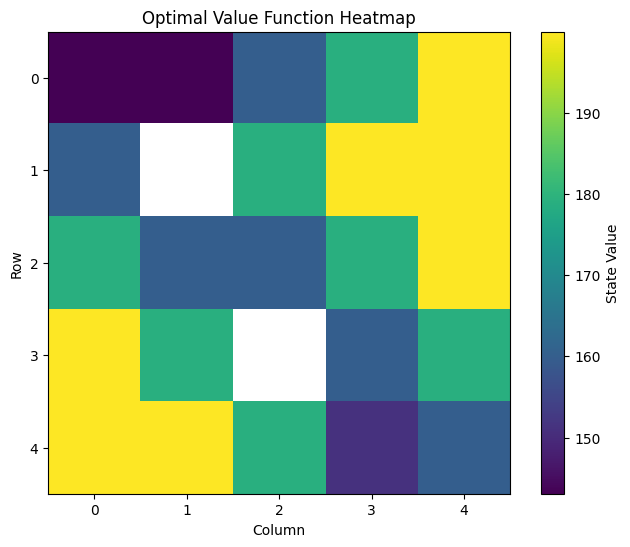

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    value_grid,
    cmap="viridis"
)

plt.colorbar(
    label="State Value"
)

plt.title(
    "Optimal Value Function Heatmap"
)

plt.xlabel("Column")

plt.ylabel("Row")

plt.show()

In [49]:
# ## Heatmap Analysis

# Observations:

# - States close to rescue targets generally have higher values.
# - States near danger zones have lower values.
# - The charging station contributes positive future rewards.
# - The heatmap clearly shows which regions are preferred by the optimal policy.

# The visualization confirms that Value Iteration successfully propagates rewards through the environment.

In [50]:
# # Task 3: Scalability Discussion

# ## Question

# How would the Dynamic Programming approach scale if:

# - Grid size increases from 5×5 to 20×20
# - Battery capacity doubles
# - Additional rescue targets are introduced

In [51]:
# ## Scalability Analysis

# Dynamic Programming suffers from the curse of dimensionality.

# Effects of increasing problem size:

# ### Larger Grid

# Increasing the grid from 5×5 to 20×20 significantly increases the number of states that must be evaluated.

# ### Larger Battery Capacity

# Battery level becomes part of the state representation.

# Doubling battery capacity increases the total state space proportionally.

# ### Additional Rescue Targets

# Each rescue target introduces additional rescue-status combinations.

# This causes exponential growth in the state space.

# ### Computational Impact

# - More memory required
# - More iterations required
# - Longer convergence time

# ### Possible Solutions

# For larger environments:

# - Deep Q-Networks (DQN)
# - Policy Gradient Methods
# - Actor-Critic Methods

# are more suitable than classical Dynamic Programming.

In [ ]:
# # Final Conclusion

# ## Dynamic Programming Assignment Summary

# A custom Drone Rescue Environment was designed and implemented for Group 222.

# The environment included:

# - Start Position
# - Rescue Targets
# - Charging Station
# - Danger Zones
# - Wind Zone
# - Blocked Cells

# Value Iteration was used to compute:

# - Optimal Value Function V(s)
# - Optimal Policy π(s)

# Results:

# - Convergence achieved successfully.
# - Optimal actions were extracted for all reachable states.
# - Heatmap visualization demonstrated reward propagation.
# - Scalability limitations of Dynamic Programming were analyzed.

# Therefore, Dynamic Programming provides an effective solution for small and medium-sized Markov Decision Processes and serves as a foundation for more advanced Reinforcement Learning algorithms.